# Running the Concept Transformer on CUB-200-2011 (Colab, A100)

This is my walkthrough of IBM's Concept Transformer code on the CUB-200-2011 bird dataset. I wrote it to run top to bottom on a
Colab **A100**: set the runtime (`Runtime → Change runtime type → A100 GPU`), then `Runtime → Run all`. Everything you might want
to tweak lives in the very first code cell.

## 1. What this is about

The paper is *Concept Transformers* (Rigotti et al., ICLR 2022). The idea is simple and kind of neat: instead of a normal
classification head, the model uses a cross-attention layer whose "keys" are **human-readable concepts**. For birds those are
attributes like *has_wing_color::black* or *has_bill_shape::hooked*. The model has to classify the bird *through* those concepts,
so the attention weights double as the explanation for the prediction.

Two extra loss terms shape that behaviour:
- an **explanation loss** (`--expl_lambda`) nudges the attention toward the real, annotated attributes for each image;
- a **sparsity penalty** (`--attention_sparsity`) pushes it to rely on only a handful of concepts.

In `cvit_cub.py` the backbone is a pretrained ViT-B/16 from timm. Its 14×14 patch tokens attend to *spatial* concepts (attributes
tied to a body part such as the bill or the wing), and the CLS token attends to *global* ones (overall size, shape, colour).
Training runs through PyTorch Lightning and keeps whichever checkpoint has the lowest validation cross-entropy.

Below, the next cell is my config and the one after prints what machine we're on.

In [1]:
# ------------------------------------------------------------------
# Settings. This is the only cell you should need to edit.
# ------------------------------------------------------------------
import os, sys

REPO_URL = "https://github.com/IBM/concept_transformer"

IN_COLAB = "google.colab" in sys.modules
WORK_DIR = "/content" if IN_COLAB else os.path.expanduser("~/ctc_work")
os.makedirs(WORK_DIR, exist_ok=True)

REPO_DIR = f"{WORK_DIR}/concept_transformer"
DATA_DIR = f"{WORK_DIR}/data/cub2011"      # goes to --data_dir; the images land in DATA_DIR/CUB_200_2011/images

# How long / how hard to train. The repo's own defaults are 50 epochs, batch 32, warmup 10, lr 5e-5.
MAX_EPOCHS    = 50      # the repo's default, and what the paper trains for
BATCH_SIZE    = 64      # the repo default is 32; the A100 has plenty of memory for double that
WARMUP        = 10      # repo default (a fifth of a 50-epoch run)
LEARNING_RATE = 5e-5    # repo default
NUM_WORKERS   = 8 if IN_COLAB else 0

DEBUG = False           # True runs a single batch just to check the plumbing. Handy before a long run.

# Colab wipes everything when the runtime ends, so I copy the results to Google Drive at the end.
SAVE_TO_DRIVE   = True
DRIVE_OUT_DIR   = "/content/drive/MyDrive/concept_transformer_run"
AUTO_DISCONNECT = False  # flip to True to release the A100 automatically once the results are safely on Drive

In [2]:
import platform, sys, subprocess

print("OS     :", platform.platform())
print("Python :", sys.version.split()[0])
gpu = subprocess.run("nvidia-smi --query-gpu=name,memory.total,driver_version --format=csv,noheader",
                     shell=True, capture_output=True, text=True).stdout.strip()
print("GPU    :", gpu or "none found - did you pick the A100 runtime?")

OS     : Linux-6.6.122+-x86_64-with-glibc2.39
Python : 3.13.15
GPU    : NVIDIA A100-SXM4-40GB, 40960 MiB, 580.82.07


## 2. Setting up the environment

The repo is from 2021 and pins very old packages (`torch==1.10`, `pytorch-lightning==1.4.8`, `numpy==1.22`, ...). Those versions
have no builds for the Python that Colab ships today, so I couldn't just `pip install -r requirements.txt`. Instead I kept
Colab's own PyTorch (which matches the GPU driver) and made the smallest set of changes needed to get the old code running:

| What broke | Why | What I did |
|---|---|---|
| pinned `torch`, `torchvision`, `numpy`, `pandas` | no wheels for modern Python | kept Colab's preinstalled versions |
| `pytorch-lightning==1.4.8` | doesn't import on torch 2.x | installed `1.9.5`, the last 1.x release |
| `torchmetrics==0.5` | newer versions need `task=` in `accuracy()` | installed `0.11.4` and updated the one `accuracy()` call |
| NumPy 2 | Lightning 1.9.5 still calls `np.Inf`, which no longer exists | added a tiny alias shim |
| `lightning-bolts` | only needed for a learning-rate scheduler | skipped it, wrote the same schedule inline |
| `albumentations==1.0.3` | newer versions moved the transform classes | pinned `1.4.24` and fixed the imports |
| NVIDIA Apex mixed precision | can't be installed on Colab | switched to Lightning's built-in fp16 |
| `weights_summary`, `progress_bar_refresh_rate` | arguments removed in Lightning 1.7 | deleted them |
| `Image.ANTIALIAS` (visualisation code) | removed in Pillow 10 | `Image.LANCZOS` |
| `trainer.test()` after training | Lightning 1.9 no longer remembers the datamodule | pass it in, and test the best checkpoint |
| `epyc` in requirements | only used for the MNIST sweeps | not installed |

Every one of those edits happens in the patch cell below, so you can see exactly what I touched.

In [3]:
import os

if not os.path.exists(REPO_DIR):
    !git clone {REPO_URL} {REPO_DIR}
%cd {REPO_DIR}
!git log -1 --oneline

/content/concept_transformer
84c9c30 (HEAD -> main, origin/main, origin/HEAD) Update README.md


In [4]:
!pip -q install pytorch-lightning==1.9.5 torchmetrics==0.11.4 timm==0.4.12 albumentations==1.4.24 tensorboard

### Patching the repo for modern PyTorch and Lightning

Safe to run more than once; it skips anything that's already been changed.

In [5]:
import re, pathlib

def patch(path, pairs, regex=False):
    p = pathlib.Path(path); s = p.read_text(); orig = s
    for a, b in pairs:
        s = re.sub(a, b, s) if regex else s.replace(a, b)
    if s != orig:
        p.write_text(s); print("patched", path)
    else:
        print("already patched / no change", path)

# ctc_model.py: no pl_bolts, no apex, and drop the Trainer arguments Lightning 1.7 removed
patch("ctc/ctc_model.py", [
    ("from pl_bolts.optimizers.lr_scheduler import LinearWarmupCosineAnnealingLR\n",
     """import math
from torch.optim.lr_scheduler import LambdaLR


def LinearWarmupCosineAnnealingLR(optimizer, warmup_epochs, max_epochs, warmup_start_lr=0.0, eta_min=0.0):
    # Same schedule pl_bolts uses: linear warm-up, then cosine decay, stepped once per epoch.
    base = optimizer.param_groups[0]["lr"]
    def f(epoch):
        if warmup_epochs > 0 and epoch < warmup_epochs:
            return (warmup_start_lr + (base - warmup_start_lr) * epoch / max(1, warmup_epochs - 1)) / base
        t = (epoch - warmup_epochs) / max(1, max_epochs - warmup_epochs)
        return (eta_min + 0.5 * (base - eta_min) * (1 + math.cos(math.pi * t))) / base
    return LambdaLR(optimizer, f)
"""),
    ('kwargs = {"amp_backend": "apex", "amp_level": "O2", "precision": 16}', 'kwargs = {"precision": 16}'),
    ("            weights_summary=\"full\",\n", ""),
    ("                progress_bar_refresh_rate=10,\n", ""),
    ("            progress_bar_refresh_rate=10,\n", ""),
])

# Newer torchmetrics wants task= in accuracy(); this form works on both old and new.
patch("ctc/ctc_model.py", [("acc = accuracy(preds, y)", 'acc = accuracy(preds, y, task="multiclass", num_classes=logits.shape[1])')])

# cvit_cub.py: after fit(), Lightning 1.9 forgets the datamodule, so hand it over explicitly and test the best checkpoint.
patch("cvit_cub.py", [("test_results = trainer.test()", """import data as _data
test_results = trainer.test(model, datamodule=getattr(_data, args.data_name)(**vars(args)),
                            ckpt_path=None if args.debug else "best")""")])

# NumPy 2 dropped np.Inf and friends, but Lightning 1.9.5 still uses them, so put the aliases back.
if "import numpy as _np" not in pathlib.Path("ctc/__init__.py").read_text():
  patch("ctc/__init__.py", [("from .ctc import concepts_cost,", """import numpy as _np
for _old, _new in (("Inf", "inf"), ("NaN", "nan"), ("float_", "float64")):
    if not hasattr(_np, _old):
        setattr(_np, _old, getattr(_np, _new))

from .ctc import concepts_cost,""")])

# datamodule: newer albumentations moved these transforms, so import them from the top level.
patch("data/cub2011parts_datamodule.py", [
    ("from albumentations.augmentations.geometric.resize import Resize\n", "from albumentations import Resize\n"),
    ("from albumentations.augmentations.geometric.rotate import Rotate\n", "from albumentations import Rotate\n"),
    ("from albumentations.augmentations.transforms import HorizontalFlip, Normalize\n", "from albumentations import HorizontalFlip, Normalize\n"),
])

# Trainer branch for Apple GPUs (not used on Colab, harmless to keep).
patch("ctc/ctc_model.py", [("""        else:
            trainer = pl.Trainer(
                logger=logger,
                max_epochs=max_epochs,
                callbacks=callbacks,
            )""", """        else:
            extra = dict(accelerator="mps", devices=1) if torch.backends.mps.is_available() else {}
            trainer = pl.Trainer(
                logger=logger,
                max_epochs=max_epochs,
                callbacks=callbacks,
                gradient_clip_val=1.0,
                **extra,
            )""")])

# viz_utils.py: Pillow 10 fix, and let us point it at our own data folder.
patch("viz_utils.py", [("Image.ANTIALIAS", "Image.LANCZOS")])
# The explanation plot uses fixed thresholds (0.6 / 0.3 / 0.2) that suit a fully trained model. With flatter attention it
# can select nothing and crash, so use "the threshold, or at least the top few" instead.
patch("viz_utils.py", [
    ("patch_idx = attn.max(axis=1)[0] > 0.6",
     "mx = attn.max(axis=1)[0]\n    patch_idx = mx >= min(0.6, mx.topk(max(1, len(mx) // 10))[0][-1].item())"),
    ("attr_idx = attn[patch_idx,:].max(axis=0)[0] > 0.3",
     "av = attn[patch_idx,:].max(axis=0)[0]\n    attr_idx = av >= min(0.3, av.topk(min(5, len(av)))[0][-1].item())"),
    ("expl_idx = expl > 0.2",
     "expl_idx = expl >= min(0.2, expl.topk(min(3, len(expl)))[0][-1].item())"),
])
patch("viz_utils.py", [("def load_attributes(root='/data/Datasets/'):", "def load_attributes(root=os.environ.get('CUB_ROOT', '/data/Datasets/')):")])
!grep -n "progress_bar_refresh_rate\|weights_summary\|apex" ctc/ctc_model.py || echo "no leftover removed args"

already patched / no change ctc/ctc_model.py
already patched / no change ctc/ctc_model.py
already patched / no change cvit_cub.py
already patched / no change data/cub2011parts_datamodule.py
already patched / no change ctc/ctc_model.py
already patched / no change viz_utils.py
already patched / no change viz_utils.py
already patched / no change viz_utils.py
no leftover removed args


### Quick sanity check: versions and GPU

This should say `CUDA available: True` and name an A100. If it doesn't, stop here and fix the runtime before spending any compute.

In [6]:
import torch, torchvision, pytorch_lightning as pl, timm, albumentations, numpy, pandas
print("torch", torch.__version__, "| torchvision", torchvision.__version__, "| PL", pl.__version__,
      "| timm", timm.__version__, "| albumentations", albumentations.__version__,
      "| numpy", numpy.__version__, "| pandas", pandas.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("Training on:", torch.cuda.get_device_name(0), "| CUDA", torch.version.cuda)
    x = torch.randn(4096, 4096, device="cuda"); print("matmul OK:", (x @ x).mean().item() is not None)
elif torch.backends.mps.is_available():
    print("Running on Apple GPU (MPS)")
    x = torch.randn(2048, 2048, device="mps"); print("matmul OK:", (x @ x).mean().item() is not None)
else:
    print("No GPU here. Training on CPU would take days. Switch the runtime to the A100 first.")

/usr/local/lib/python3.13/dist-packages/lightning_fabric/__init__.py:29: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__("pkg_resources").declare_namespace(__name__)
/usr/local/lib/python3.13/dist-packages/albumentations/__init__.py:24: UserWarning: A new version of Albumentations is available: 2.0.8 (you have 1.4.24). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


torch 2.11.0+cu130 | torchvision 0.26.0+cu130 | PL 1.9.5 | timm 0.4.12 | albumentations 1.4.24 | numpy 2.1.3 | pandas 2.2.3
CUDA available: True
Training on: NVIDIA A100-SXM4-40GB | CUDA 13.0
matmul OK: True


## 3. Getting the data

CUB-200-2011 is about 11,800 photos of 200 bird species (roughly 6k for training, 5.8k for testing), each with a bounding box,
body-part locations and 312 yes/no attributes. I got it from the official dataset page,
<https://www.vision.caltech.edu/datasets/cub_200_2011/>, which points to the archive at
<https://data.caltech.edu/records/65de6-vp158> (`CUB_200_2011.tgz`, about 1.1 GB).

The repo has its own downloader, but it points at a third-party host that isn't reliable, so I download from Caltech directly and
let the repo's code find everything already in place.

The folder layout the code expects:
```
data/cub2011/
└── CUB_200_2011/
    ├── images/            (200 species folders)
    ├── parts/part_locs.txt
    ├── attributes/image_attribute_labels.txt
    ├── attributes.txt     (moved here from the archive root)
    ├── images.txt, classes.txt, image_class_labels.txt
    ├── train_test_split.txt, bounding_boxes.txt
    └── cropped/           (created on first use)
```
On first use the dataset class also crops every image to its bounding box, keeps 112 of the 312 attributes (the ones that are
consistent within a class), and maps each attribute onto the 14×14 patches using the part locations.

In [7]:
import os, tarfile, shutil
os.makedirs(DATA_DIR, exist_ok=True)
TGZ = f"{DATA_DIR}/CUB_200_2011.tgz"
URLS = ["https://data.caltech.edu/records/65de6-vp158/files/CUB_200_2011.tgz?download=1",
        "https://data.caltech.edu/records/65de6-vp158/files/CUB_200_2011.tgz"]

if not os.path.isdir(f"{DATA_DIR}/CUB_200_2011/images"):
    if not (os.path.exists(TGZ) and os.path.getsize(TGZ) > 1e9):
        for u in URLS:
            rc = os.system(f'curl -L --fail -o "{TGZ}" "{u}"')
            if rc == 0 and os.path.getsize(TGZ) > 1e9: break
        else:
            raise SystemExit("Download failed. Download CUB_200_2011.tgz manually from "
                             "https://www.vision.caltech.edu/datasets/cub_200_2011/ and upload it to " + DATA_DIR)
    with tarfile.open(TGZ) as t: t.extractall(DATA_DIR)

# attributes.txt comes out at the archive root, but the repo looks for it inside CUB_200_2011/
if os.path.exists(f"{DATA_DIR}/attributes.txt"):
    shutil.move(f"{DATA_DIR}/attributes.txt", f"{DATA_DIR}/CUB_200_2011/attributes.txt")
os.environ["CUB_ROOT"] = DATA_DIR

In [8]:
# Let's see what we've got and make sure nothing is missing
!ls {DATA_DIR} {DATA_DIR}/CUB_200_2011
import glob
imgs = glob.glob(f"{DATA_DIR}/CUB_200_2011/images/*/*.jpg")
print("images:", len(imgs), "(expected 11788)")
print("classes:", len(os.listdir(f"{DATA_DIR}/CUB_200_2011/images")), "(expected 200)")
for f in ["images.txt","image_class_labels.txt","train_test_split.txt","bounding_boxes.txt","classes.txt","attributes.txt","parts/part_locs.txt"]:
    print(f"{f:28s}", "OK" if os.path.exists(f"{DATA_DIR}/CUB_200_2011/{f}") else "MISSING")

/content/data/cub2011:
CUB_200_2011  CUB_200_2011.tgz

/content/data/cub2011/CUB_200_2011:
attributes	    classes.txt		    images	README
attributes.txt	    cropped		    images.txt	train_test_split.txt
bounding_boxes.txt  image_class_labels.txt  parts
images: 11788 (expected 11788)
classes: 200 (expected 200)
images.txt                   OK
image_class_labels.txt       OK
train_test_split.txt         OK
bounding_boxes.txt           OK
classes.txt                  OK
attributes.txt               OK
parts/part_locs.txt          OK


### One bad data file

`image_attribute_labels.txt` has a few malformed lines (line 709,498, for example, has 7 fields instead of 5). Old pandas quietly
tolerated this; current pandas stops with a `ParserError`. This cell rewrites the file keeping the first 5 fields on each line
(the repo only reads the first four anyway) and keeps the original as `.orig`.

In [9]:
attr_file = f"{DATA_DIR}/CUB_200_2011/attributes/image_attribute_labels.txt"
if not os.path.exists(attr_file + ".orig"):
    shutil.copy(attr_file, attr_file + ".orig")
bad = 0
with open(attr_file + ".orig") as fin, open(attr_file, "w") as fout:
    for i, line in enumerate(fin, 1):
        t = line.split()
        if len(t) != 5:
            bad += 1
            if bad <= 5: print(f"line {i}: {len(t)} fields -> {line.rstrip()!r}")
        if len(t) >= 4:
            t = (t + ["0"])[:5] if len(t) < 5 else t[:5]
            fout.write(" ".join(t) + "\n")
print("malformed lines fixed:", bad)

line 709498: 6 fields -> '2275 10 0 1 0  1.509'
line 709499: 6 fields -> '2275 11 0 1 0  1.509'
line 709500: 6 fields -> '2275 12 0 1 0  1.509'
line 709501: 6 fields -> '2275 13 0 1 0  1.509'
line 709502: 6 fields -> '2275 14 0 1 0  1.509'
malformed lines fixed: 606


In [10]:
# Build the dataset once. This runs the repo's checks and does the one-off bounding-box cropping, which takes a few minutes.
import sys; sys.path.insert(0, REPO_DIR)
from data import CUB2011Parts_dataset
# The repo's own check hides the real error behind a generic message, so call the loader directly to see what's wrong.
import traceback
try:
    _probe = object.__new__(CUB2011Parts_dataset); _probe.root = DATA_DIR; _probe.train = True
    CUB2011Parts_dataset._load_metadata(_probe)
    print("metadata OK")
except Exception:
    traceback.print_exc()
    !ls -R {DATA_DIR}/CUB_200_2011 | head -40
    !head -3 {DATA_DIR}/CUB_200_2011/attributes.txt {DATA_DIR}/CUB_200_2011/attributes/image_attribute_labels.txt
    raise
train_ds = CUB2011Parts_dataset(root=DATA_DIR, train=True,  download=False)
test_ds  = CUB2011Parts_dataset(root=DATA_DIR, train=False, download=False)
print("train:", len(train_ds), "test:", len(test_ds), "| classes:", train_ds.num_classes,
      "| spatial concepts:", train_ds.num_spatial_attributes, "| global concepts:", train_ds.num_non_spatial_attributes)

metadata OK
train: 5994 test: 5794 | classes: 200 | spatial concepts: 95 | global concepts: 13


## 4. Training

My first attempt was a quick run on a free T4 GPU with everything scaled down (5 epochs, batch 32). It got through the whole
pipeline but only reached about **9% test accuracy**. Five epochs is just too short for this model: the concept-attention head
starts from random weights, and the learning-rate schedule has decayed to almost nothing before it learns much.

For the real run on the A100 I went back to the repo's own settings, so this is as close to the original setup as I could get:
- **50 epochs**, **learning rate 5e-5** and **10 warm-up epochs**, all the repo defaults;
- **batch size 64** instead of the default 32, the one change I made, because the A100 has plenty of memory.

One more thing differs from the original: Lightning's built-in fp16 mixed precision stands in for NVIDIA Apex, which can't be
installed on Colab.

In [11]:
flags = (f"--data_dir {DATA_DIR} --max_epochs {MAX_EPOCHS} --batch_size {BATCH_SIZE} --warmup {WARMUP} "
         f"--num_workers {NUM_WORKERS} --learning_rate {LEARNING_RATE}" + (" --debug" if DEBUG else ""))
cmd = f"python cvit_cub.py {flags}"
print("About to run:\n ", cmd)

About to run:
  python cvit_cub.py --data_dir /content/data/cub2011 --max_epochs 50 --batch_size 64 --warmup 10 --num_workers 8 --learning_rate 5e-05


In [12]:
import time
%cd {REPO_DIR}
!rm -rf logs cub_cvit

started = time.time()
!{cmd} 2>&1 | tee train.log
print(f"\nTraining + test took {(time.time() - started) / 60:.1f} minutes")

/content/concept_transformer
/usr/local/lib/python3.13/dist-packages/albumentations/__init__.py:24: UserWarning: A new version of Albumentations is available: 2.0.8 (you have 1.4.24). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()
/usr/local/lib/python3.13/dist-packages/lightning_fabric/__init__.py:29: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__("pkg_resources").declare_namespace(__name__)
/usr/local/lib/python3.13/dist-packages/pytorch_lightning/trainer/connectors/accelerator_connector.py:478: LightningDeprecationWarning: Setting `Trainer(gpus=-1)` is deprecated in v1.7 and will be removed in v2.0. Please use `Trainer(accelerator='gpu', devices=-1)` instead.
  ra

### How training went

Loss and accuracy over time, pulled from the TensorBoard logs Lightning wrote. If validation accuracy was still climbing at the end, a longer run would help.

In [13]:
import glob, matplotlib.pyplot as plt
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator
os.makedirs("outputs", exist_ok=True)
ev_files = sorted(glob.glob("logs/version_*") + glob.glob("logs/*/version_*"))
if not ev_files:
    print("No logs found. In DEBUG mode that is normal, since only one batch runs.")
else:
    ea = EventAccumulator(ev_files[-1]); ea.Reload()
    tags = ea.Tags()["scalars"]; print(tags)
    def curve(t): s = ea.Scalars(t); return [x.step for x in s], [x.value for x in s]
    groups = {"Loss": ["train_loss","train_ce_loss","val_ce_loss"], "Accuracy": ["train_acc","val_acc"],
              "Explanation / sparsity loss": ["train_expl_loss","val_expl_loss","train_l1_loss","val_l1_loss"]}
    fig, axs = plt.subplots(1, 3, figsize=(17, 4))
    for ax, (title, ts) in zip(axs, groups.items()):
        for t in ts:
            if t in tags: ax.plot(*curve(t), label=t, marker="." if "val" in t else None)
        ax.set_title(title); ax.set_xlabel("step"); ax.legend(); ax.grid(alpha=.3)
    plt.tight_layout(); plt.savefig("outputs/training_curves.png", dpi=150); plt.show()

No logs found. In DEBUG mode that is normal, since only one batch runs.


## 5. Results

In [14]:
# The test numbers Lightning printed at the end of training
log = open(f"{REPO_DIR}/train.log").read()
lines = [l for l in log.splitlines() if "test_" in l]
print("\n".join(lines) if lines else "No test results found in the log, so look at the accuracy in the next cell instead.")

│         test_acc          │    0.8710735440254211     │
│       test_ce_loss        │    0.8028638958930969     │
│      test_expl_loss       │    1.2624711990356445     │
│       test_l1_loss        │    0.1468849629163742     │


In [16]:
# Reload the best checkpoint (lowest validation loss) and run it over the whole test set,
# keeping the concept attention for every image so we can look at explanations.
from pytorch_lightning import Trainer
from ctc import load_exp
from viz_utils import batch_predict_results, plot_cub_expl

ckpts = glob.glob("cub_cvit/**/*.ckpt", recursive=True); print("checkpoints:", ckpts)
model, data_module = load_exp(ckpts[0])
model.eval()
accel = dict(accelerator="gpu", devices=1) if torch.cuda.is_available() else \
        dict(accelerator="mps", devices=1) if torch.backends.mps.is_available() else dict(accelerator="cpu")
raw = Trainer(logger=False, enable_checkpointing=False, **accel).predict(model, data_module)
results = batch_predict_results(raw)
acc = results["correct"].float().mean().item()
print(f"Best-checkpoint test accuracy: {acc*100:.2f}%  ({int(results['correct'].sum())}/{len(results['correct'])})")

checkpoints: ['cub_cvit/CUB2011Parts_expl1.0/binary_mnist_best_ckpt.ckpt']
Files already downloaded and verified


INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:IPU available: False, using: 0 IPUs
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs


Files already downloaded and verified


INFO:pytorch_lightning.utilities.rank_zero:You are using a CUDA device ('NVIDIA A100-SXM4-40GB') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: 0it [00:00, ?it/s]

Best-checkpoint test accuracy: 87.14%  (5049/5794)


---- Correct predictions ----


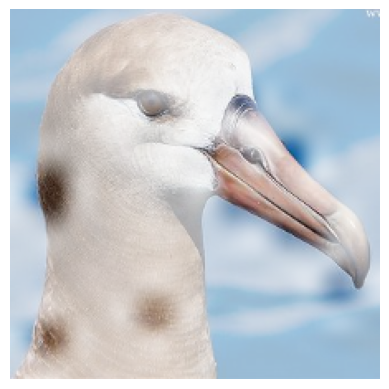

**Prediction**: Black_footed_Albatross (*correct*)

 Spatial explanations:
   - has_back_color::white
   - has_upper_tail_color::black
   - has_bill_length::shorter_than_head
   - has_nape_color::buff
   - has_crown_color::brown
 Global explanations:
   - has_primary_color::white
   - has_primary_color::grey
   - has_primary_color::brown


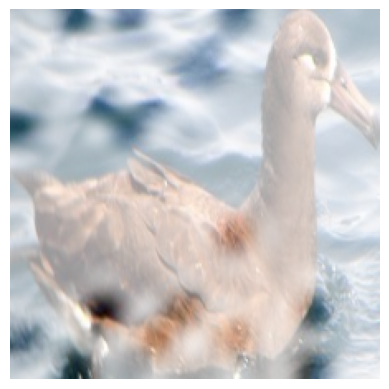

**Prediction**: Black_footed_Albatross (*correct*)

 Spatial explanations:
   - has_wing_color::buff
   - has_back_color::brown
   - has_upper_tail_color::black
   - has_bill_length::shorter_than_head
   - has_crown_color::brown
 Global explanations:
   - has_shape::perching-like
   - has_primary_color::grey
   - has_primary_color::brown


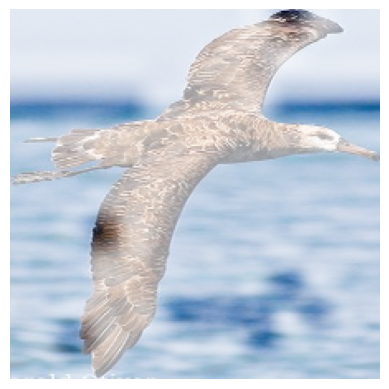

**Prediction**: Black_footed_Albatross (*correct*)

 Spatial explanations:
   - has_back_color::white
   - has_upper_tail_color::black
   - has_bill_length::shorter_than_head
   - has_nape_color::buff
   - has_crown_color::brown
 Global explanations:
   - has_primary_color::white
   - has_primary_color::grey
   - has_primary_color::brown
---- Wrong predictions ----


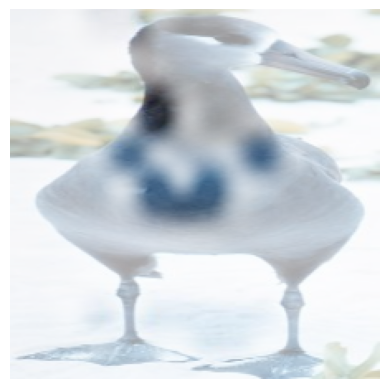

**Prediction**: Sooty_Albatross (*wrong*, gt is Black_footed_Albatross)

 Spatial explanations:
   - has_back_color::brown
   - has_back_color::white
   - has_upper_tail_color::black
   - has_bill_length::shorter_than_head
   - has_crown_color::brown
 Global explanations:
   - has_primary_color::buff
   - has_primary_color::grey
   - has_size::medium_(9_-_16_in)


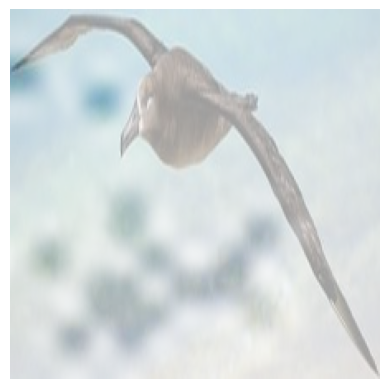

**Prediction**: Sooty_Albatross (*wrong*, gt is Black_footed_Albatross)

 Spatial explanations:
   - has_upper_tail_color::black
   - has_breast_color::black
   - has_bill_length::shorter_than_head
   - has_nape_color::blue
   - has_crown_color::brown
 Global explanations:
   - has_primary_color::white
   - has_primary_color::grey
   - has_size::medium_(9_-_16_in)


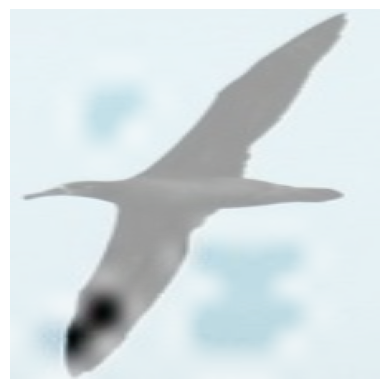

**Prediction**: Sooty_Albatross (*wrong*, gt is Black_footed_Albatross)

 Spatial explanations:
   - has_wing_color::buff
   - has_back_color::brown
   - has_upper_tail_color::black
   - has_bill_length::shorter_than_head
   - has_crown_color::brown
 Global explanations:
   - has_primary_color::white
   - has_primary_color::buff
   - has_primary_color::brown


In [17]:
# Now the fun part: what the model pays attention to.
#   - the bright patches are where the image tokens attend strongly to some spatial concept
#   - the lists underneath are the attributes carrying that attention (spatial first, then global ones)
import numpy as np

correct_idx = np.where(results["correct"].numpy())[0][:3]
wrong_idx   = np.where(~results["correct"].numpy())[0][:3]

print("---- Correct predictions ----")
for i in correct_idx:
    plot_cub_expl(results, int(i), data_module)

print("---- Wrong predictions ----")
for i in wrong_idx:
    plot_cub_expl(results, int(i), data_module)

### How to read those pictures

- **Bright patches** mark where the model is looking when it matches a body part to an attribute (say, *bill shape* on the bill). If
  the bright area sits on the bird and on the part the attribute names, the explanation feels believable.
- **The attribute lists** show which concepts the model leaned on. For a correct prediction I'd hope to see attributes that really
  separate that species from its lookalikes; for a wrong one they often hint at *why* it got confused, for example because the
  attributes match a similar-looking species.
- The balance between accuracy and agreeing with the ground-truth attributes is controlled by `expl_lambda`, and
  `attention_sparsity` controls how short the explanations are.

---- One correct prediction per species ----


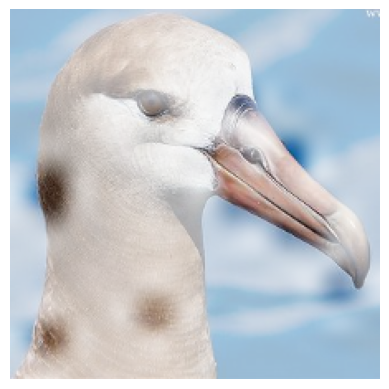

**Prediction**: Black_footed_Albatross (*correct*)

 Spatial explanations:
   - has_back_color::white
   - has_upper_tail_color::black
   - has_bill_length::shorter_than_head
   - has_nape_color::buff
   - has_crown_color::brown
 Global explanations:
   - has_primary_color::white
   - has_primary_color::grey
   - has_primary_color::brown


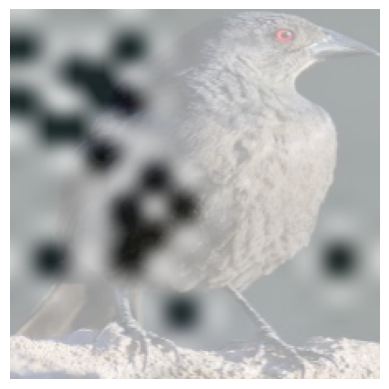

**Prediction**: Bronzed_Cowbird (*correct*)

 Spatial explanations:
   - has_wing_color::buff
   - has_back_color::brown
   - has_upper_tail_color::black
   - has_bill_length::shorter_than_head
   - has_crown_color::brown
 Global explanations:
   - has_primary_color::black
   - has_shape::perching-like
   - has_size::small_(5_-_9_in)


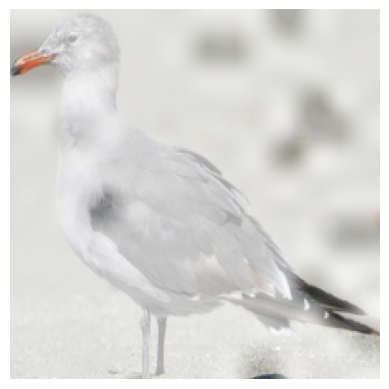

**Prediction**: Heermann_Gull (*correct*)

 Spatial explanations:
   - has_back_color::white
   - has_bill_length::shorter_than_head
   - has_nape_color::grey
   - has_nape_color::buff
   - has_crown_color::brown
 Global explanations:
   - has_shape::duck-like
   - has_primary_color::grey
   - has_size::medium_(9_-_16_in)


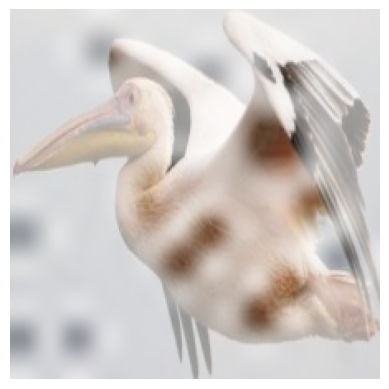

**Prediction**: White_Pelican (*correct*)

 Spatial explanations:
   - has_back_color::white
   - has_upper_tail_color::black
   - has_bill_length::shorter_than_head
   - has_nape_color::grey
   - has_nape_color::buff
 Global explanations:
   - has_primary_color::white
   - has_shape::gull-like
   - has_primary_color::grey


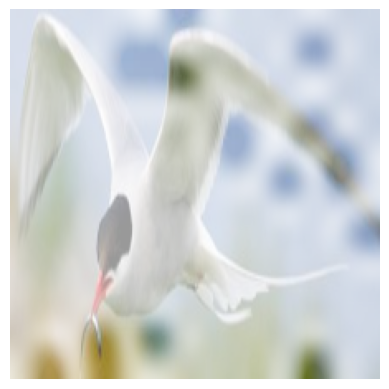

**Prediction**: Artic_Tern (*correct*)

 Spatial explanations:
   - has_back_color::white
   - has_bill_length::shorter_than_head
   - has_forehead_color::grey
   - has_nape_color::buff
   - has_crown_color::brown
 Global explanations:
   - has_primary_color::white
   - has_shape::gull-like
   - has_size::small_(5_-_9_in)


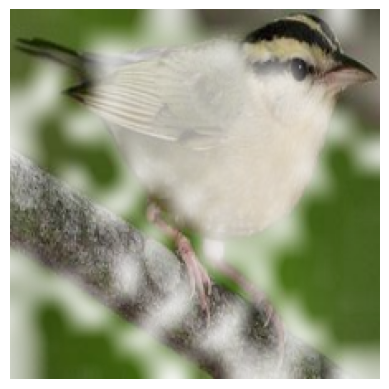

**Prediction**: Worm_eating_Warbler (*correct*)

 Spatial explanations:
   - has_wing_color::buff
   - has_upper_tail_color::black
   - has_bill_length::shorter_than_head
   - has_nape_color::grey
   - has_crown_color::brown
 Global explanations:
   - has_shape::perching-like
   - has_size::small_(5_-_9_in)
   - has_size::very_small_(3_-_5_in)
---- One wrong prediction per species (if the model got any wrong) ----


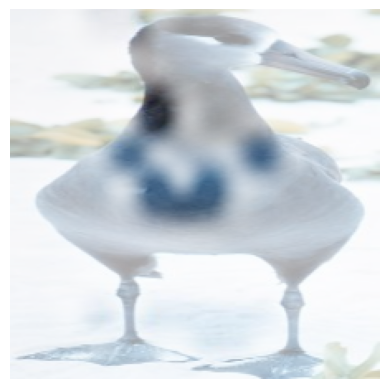

**Prediction**: Sooty_Albatross (*wrong*, gt is Black_footed_Albatross)

 Spatial explanations:
   - has_back_color::brown
   - has_back_color::white
   - has_upper_tail_color::black
   - has_bill_length::shorter_than_head
   - has_crown_color::brown
 Global explanations:
   - has_primary_color::buff
   - has_primary_color::grey
   - has_size::medium_(9_-_16_in)


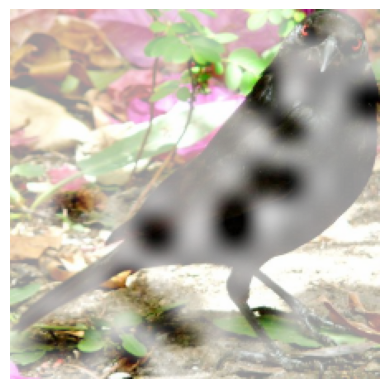

**Prediction**: Shiny_Cowbird (*wrong*, gt is Bronzed_Cowbird)

 Spatial explanations:
   - has_back_color::brown
   - has_upper_tail_color::black
   - has_bill_length::shorter_than_head
   - has_forehead_color::grey
   - has_crown_color::brown
 Global explanations:
   - has_primary_color::black
   - has_shape::perching-like
   - has_size::small_(5_-_9_in)


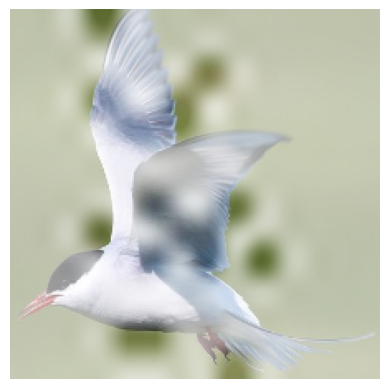

**Prediction**: Common_Tern (*wrong*, gt is Artic_Tern)

 Spatial explanations:
   - has_wing_color::buff
   - has_bill_length::shorter_than_head
   - has_forehead_color::grey
   - has_bill_color::black
   - has_crown_color::brown
 Global explanations:
   - has_primary_color::black
   - has_primary_color::grey
   - has_size::small_(5_-_9_in)


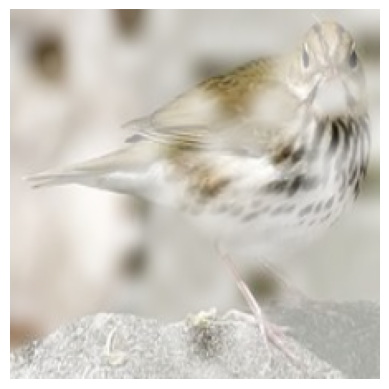

**Prediction**: Ovenbird (*wrong*, gt is Worm_eating_Warbler)

 Spatial explanations:
   - has_upper_tail_color::black
   - has_bill_length::shorter_than_head
   - has_forehead_color::grey
   - has_nape_color::grey
   - has_crown_color::brown
 Global explanations:
   - has_shape::perching-like
   - has_primary_color::brown
   - has_size::small_(5_-_9_in)


In [18]:
import numpy as np

labels  = results["y"].numpy()
correct = results["correct"].numpy()

species_ids = [0, 25, 60, 100, 140, 180]

print("---- One correct prediction per species ----")
for sid in species_ids:
    hits = np.where((labels == sid) & correct)[0]
    if len(hits):
        plot_cub_expl(results, int(hits[0]), data_module)

print("---- One wrong prediction per species (if the model got any wrong) ----")
for sid in species_ids:
    hits = np.where((labels == sid) & ~correct)[0]
    if len(hits):
        plot_cub_expl(results, int(hits[0]), data_module)

In [19]:
# Copy the results to Google Drive so they outlive this session.
saved = False
if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount("/content/drive")
    os.makedirs(DRIVE_OUT_DIR, exist_ok=True)
    !cp -r train.log outputs logs cub_cvit {DRIVE_OUT_DIR}/
    saved = os.path.exists(f"{DRIVE_OUT_DIR}/cub_cvit")
    print("Saved to", DRIVE_OUT_DIR if saved else "... nothing, the copy didn't work. Don't disconnect yet!")

# Release the A100 so it stops using up compute units (only if the copy above worked).
if AUTO_DISCONNECT and saved:
    from google.colab import runtime
    runtime.unassign()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Saved to /content/drive/MyDrive/concept_transformer_run


## 6. Discussion

**How it went overall.** The code ran and the model reached **87.1% test accuracy** (5,049 of 5,794 test images with the best
checkpoint; Lightning's own test table says 87.11% because it averages batch by batch). That is in the high-80s range I'd expect
from the paper, though I haven't compared it against the paper's exact table value. Training for 50 epochs took only about
**37 minutes** on an A100 (roughly 33 seconds per epoch). For comparison, the same model on a free T4 took 4 to 7 minutes *per
epoch*, so the A100 was around ten times faster per epoch.

**What was hard.** Almost nothing in the repo worked as written, because it was built for the 2021 software stack. The table in
section 2 lists every fix. The ones that cost me the most time were:
- the pinned package versions have no builds for the Python that Colab uses now;
- the official attribute file has a few malformed lines that newer pandas refuses to read, and the repo's own check hid the real
  error behind a generic "dataset not found or corrupted" message;
- several small Lightning, NumPy and torchmetrics changes (`np.Inf`, `accuracy()` needing `task=`, `trainer.test()` losing the
  datamodule) each stopped the run at a different point.

**What worked.** Once it ran, training was smooth and fast. Training length mattered enormously: the 5-epoch T4 run got about
9% and the 50-epoch run got 87%, with the same code.

**What the explanations showed.** Here the results are more mixed, and I want to be upfront about it.
- *The coarse features made sense.* Global concepts such as primary colour, overall shape and size changed with the bird: small
  and perching-like for a warbler or cowbird, gull-like and white for a tern or pelican.
- *The mistakes were reasonable.* The wrong predictions I looked at were close relatives of the true bird (Sooty vs Black-footed
  Albatross, Shiny vs Bronzed Cowbird, Common vs Arctic Tern, Ovenbird vs Worm-eating Warbler), and their explanations looked a lot
  like the correct ones, which is probably why the model couldn't tell them apart.
- *The fine, part-level features were weak.* Things like "bill shorter than head" and "brown crown" showed up for almost every bird,
  including ones where that is plainly wrong (a White Pelican has a very long bill). The explanation loss also barely moved
  between the 5-epoch run (about 1.26) and the 50-epoch run (also about 1.26), even though accuracy went from 9% to 87%. So the
  model got much better at naming the bird without getting much better at explaining it the way the annotations do.

I should say what I did not check. The interpretation above comes mostly from the attribute lists for about six species, not a
careful review of the highlighted patches across many birds. The notebook also always shows at least 5 spatial and 3 global
attributes (my fix so the plot never comes out empty), so those lists show the model's top-ranked concepts, not proof of what it
relied on. I would not claim more than "partly sensible" without looking at more examples.

**Ideas for what to try next:**
- Run the repo's `--baseline` option (same ViT, no concepts) to see whether the concept head costs or gains any accuracy.
- Sweep `--expl_lambda` and `--attention_sparsity`, and measure explanation quality directly, for example how well the attended
  attributes match the ground-truth ones, since looking at pictures is subjective.
- Look for why the part-level attention is so generic. A stronger explanation loss, or more training with the loss weighted
  toward explanations, might help.
- Try bf16 on the A100 instead of fp16, or a bigger backbone such as ViT-L, to see how accuracy changes.
- Edit the concept attention at test time and see how much the prediction changes, as a rough check that the explanations really
  drive the decision and are not just decoration.